In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data = pd.read_csv("site_month_viirs_with_cloud_mask_joined.csv")   # your full merged TX site×month file

In [68]:
data.columns

Index(['site_id', 'date', 'oil_pipeline_bbl', 'oil_truck_bbl',
       'oil_tankcar_bbl', 'oil_tank_cleaning_bbl', 'oil_circulating_bbl',
       'oil_lost_stolen_bbl', 'oil_bsw_repressure_bbl', 'oil_legacy_bbl',
       'oil_skimmed_bbl', 'oil_scrubber_bbl', 'oil_no_disp_code_bbl',
       'csgd_field_ops_fuel_mcf', 'csgd_transmission_mcf',
       'csgd_processing_plant_mcf', 'csgd_vented_flared_mcf',
       'csgd_gas_lift_mcf', 'csgd_repressure_mcf', 'csgd_carbon_black_mcf',
       'csgd_underground_storage_mcf', 'csgd_no_disp_code_mcf',
       'oil_sold_total_bbl', 'total_vented_flared_mcf', 'year_month', 'year',
       'month', 'lat', 'lon', 'n_obs', 'n_detect', 'n_nondet', 'n_detect_cm0',
       'n_nondet_cm0', 'n_detect_cm1', 'n_nondet_cm1', 'n_detect_cm2',
       'n_nondet_cm2', 'n_detect_cm3', 'n_nondet_cm3', 'n_detect_cmNA',
       'n_nondet_cmNA', 'n_obs_SNPP', 'n_detect_SNPP', 'n_obs_NOAA20',
       'n_detect_NOAA20', 'n_obs_OTHERSAT', 'n_detect_OTHERSAT', 'rh_sum',
       'rh_n

In [69]:
prod_col = 'Volume'   # keep the NM downstream name so Cell 3 is unchanged

df = data.copy()
df = df[df['year'] >= 2013]                     # NM used min_year = 2013
# NM restricted VIIRS to sites mapped to a Permian OIL well (inner joins throughout).
# Your file has right_only rows = VIIRS sites with no production match. Toggle if needed:
# df = df[df['_merge'] == 'both']

# --- VIIRS: NM denominator is clear-ish looks = cloud mask 0 AND 1 (detect+nondetect). Matches exactly. ---
df['total_obs']     = df['n_detect_cm0'] + df['n_nondet_cm0'] + df['n_detect_cm1'] + df['n_nondet_cm1']
df['total_detects'] = df['n_detect_cm0'] + df['n_detect_cm1']
# NM numerator is rh_sum_cm0 + rh_sum_cm1. Your file has ONE all-mask rh_sum, so this term
# does NOT match NM. Using it as-is, flagged (see below), not silently fudged:
df['total_rh']      = df['rh_sum_cm0'] + df['rh_sum_cm1']

g = df.groupby('year_month')
viirs_ts = g[['total_obs', 'total_detects', 'total_rh']].sum(min_count=1)
viirs_ts['mean_rh_clear']     = viirs_ts['total_rh'] / viirs_ts['total_obs']
viirs_ts['detect_freq_clear'] = viirs_ts['total_detects'] / viirs_ts['total_obs']

# --- oil production: default to the single total-sold column; see note on matching NM's 'Volume' ---
oil_ts = g['oil_sold_total_bbl'].sum(min_count=1).rename(prod_col)
# alternative (total oil across dispositions, if NM 'Volume' is produced not sold):
# oil_cols = [c for c in df.columns if c.startswith('oil_') and c != 'oil_sold_total_bbl']
# oil_ts = g[oil_cols].sum(min_count=1).sum(axis=1).rename(prod_col)

df_ts = viirs_ts.join(oil_ts, how='inner')       # inner on month, like NM's merge
df_ts.index = pd.to_datetime(df_ts.index + '-01')
df_ts = df_ts.sort_index().loc[:'2026-01-01']    # end Jan 2026, like NM

min_year = 2013

# 4. Filter VIIRS Data: Only target years, and ONLY sites that contain our target oil wells
df_viirs_filtered = df.rename(columns={'flare_id': 'EOG_Site_ID', 'year': 'Year', 'month': 'Month'})
df_viirs_filtered = df_viirs_filtered[
    (df_viirs_filtered['Year'] >= min_year) ].copy()

# null + time-interpolate the corrupted Aug-2022 VIIRS month, like NM (DESCRIBE-only fill)
viirs_feat = ['total_obs', 'total_detects', 'total_rh', 'mean_rh_clear', 'detect_freq_clear']
if '2022-08-01' in df_ts.index:
    df_ts.loc['2022-08-01', viirs_feat] = np.nan
    df_ts[viirs_feat] = df_ts[viirs_feat].interpolate(method='time')

print(f"Range: {df_ts.index.min().date()} to {df_ts.index.max().date()}   shape: {df_ts.shape}")
df_ts.head()

Range: 2013-01-01 to 2026-01-01   shape: (157, 6)


,total_obs,total_detects,total_rh,mean_rh_clear,detect_freq_clear,Volume
year_month,,,,,,
2013-01-01,48574.0,302.0,846.725603,0.017432,0.006217,4.918195e+06
2013-02-01,48770.0,303.0,1140.465537,0.023385,0.006213,4.524573e+06
2013-03-01,56315.0,407.0,1430.340306,0.025399,0.007227,4.984617e+06
2013-04-01,57588.0,375.0,1264.053930,0.021950,0.006512,5.033527e+06
2013-05-01,49495.0,326.0,731.381303,0.014777,0.006587,5.310806e+06


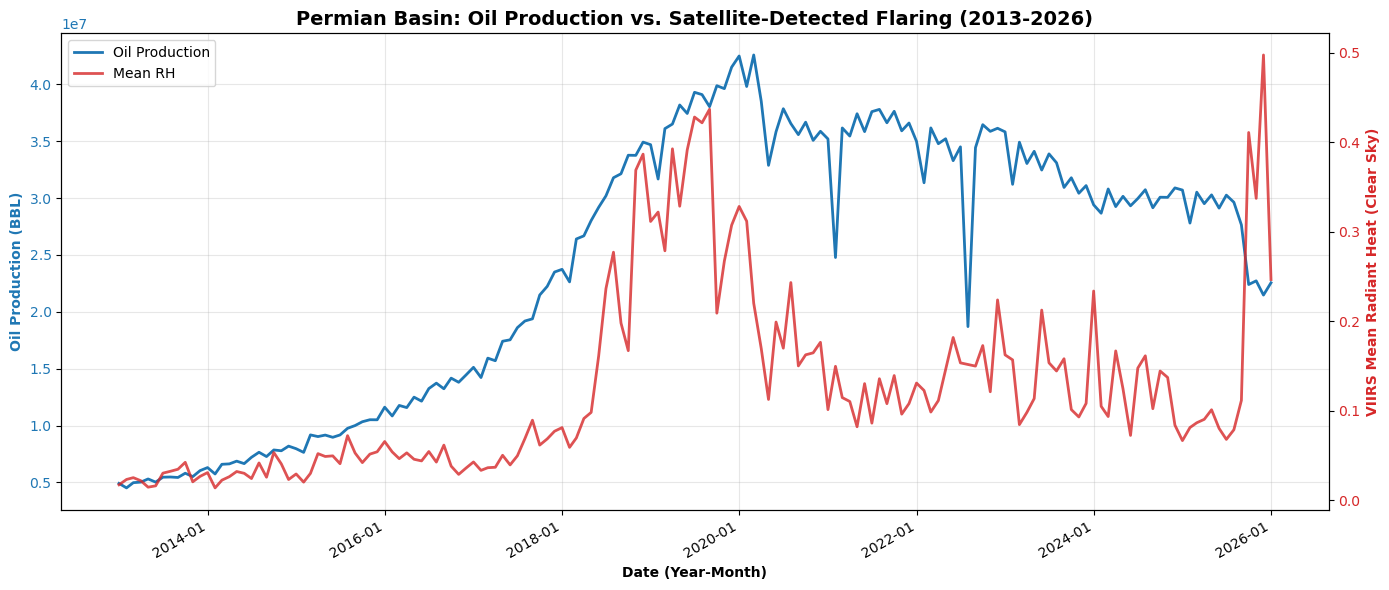

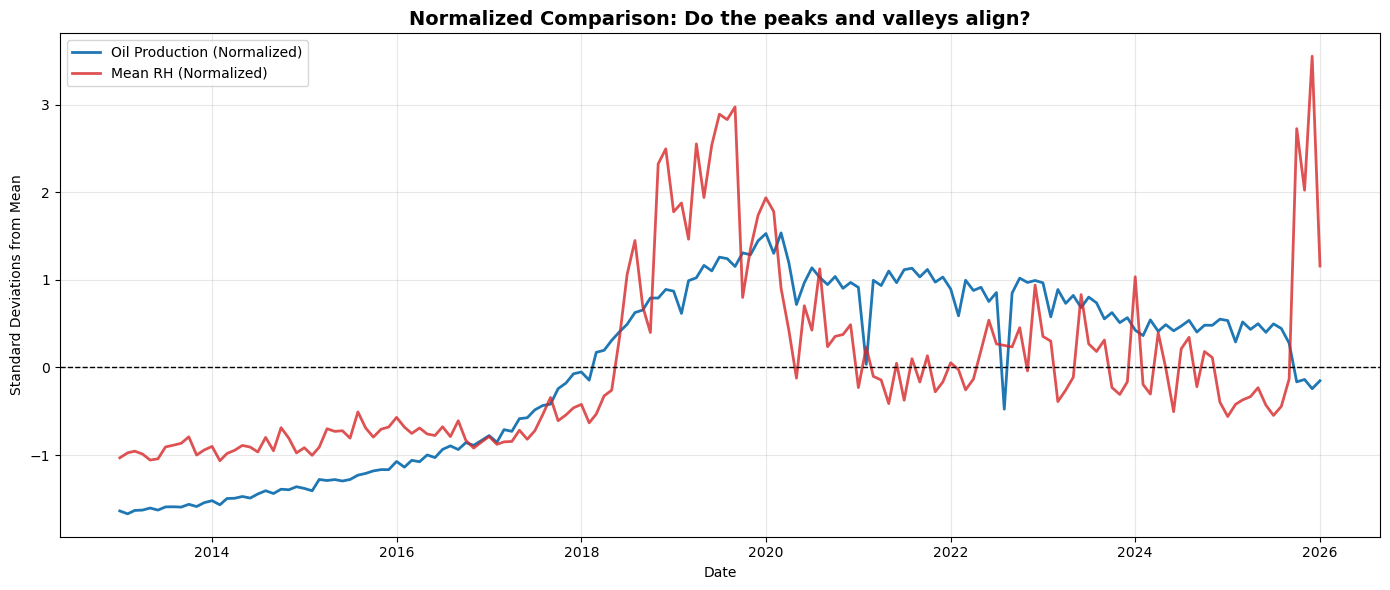

In [70]:
# =============================================================================
# 3.5. VISUAL EXPLORATION: PLOTTING THE TIME SERIES
# =============================================================================
from sklearn.preprocessing import StandardScaler

prod_col = 'Volume'
exo_feature = 'mean_rh_clear'

# --- Plot 1: Dual Y-Axis Plot (Actual Values) ---
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Date (Year-Month)', fontweight='bold')
ax1.set_ylabel('Oil Production (BBL)', color=color1, fontweight='bold')
# Plot Oil Production
line1 = ax1.plot(df_ts.index, df_ts[prod_col], color=color1, linewidth=2, label='Oil Production')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('VIIRS Mean Radiant Heat (Clear Sky)', color=color2, fontweight='bold')
# Plot VIIRS Data
line2 = ax2.plot(df_ts.index, df_ts[exo_feature], color=color2, linewidth=2, alpha=0.8, label='Mean RH')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Permian Basin: Oil Production vs. Satellite-Detected Flaring (2013-2026)', fontsize=14, fontweight='bold')
# Format the x-axis dates nicely
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# --- Plot 2: Normalized Overlay (Z-Scores) ---
# This forces both series to have a mean of 0 and std dev of 1, 
# making it incredibly easy to see if the peaks and valleys align.
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_ts[[prod_col, exo_feature]]), 
    columns=[f'{prod_col}_scaled', f'{exo_feature}_scaled'], 
    index=df_ts.index
)

plt.figure(figsize=(14, 6))
plt.plot(df_scaled.index, df_scaled[f'{prod_col}_scaled'], color='tab:blue', linewidth=2, label='Oil Production (Normalized)')
plt.plot(df_scaled.index, df_scaled[f'{exo_feature}_scaled'], color='tab:red', linewidth=2, alpha=0.8, label='Mean RH (Normalized)')

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Normalized Comparison: Do the peaks and valleys align?', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Standard Deviations from Mean')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--------------------------------------------------
1. STATIONARITY CHECKS (Augmented Dickey-Fuller)
--------------------------------------------------
[Raw Oil Volume] ADF p-value: 0.4446
  -> NOT Stationary (Needs differencing, d=1).
[Raw VIIRS Mean RH] ADF p-value: 0.2903
  -> NOT Stationary (Needs differencing, d=1).

(Checking differenced data...)
[Differenced Oil Volume] ADF p-value: 0.0000
  -> Stationary (d=0).
[Differenced VIIRS Mean RH] ADF p-value: 0.0000
  -> Stationary (d=0).

--------------------------------------------------
2. GRANGER CAUSALITY TEST
--------------------------------------------------
H0: Past VIIRS values do NOT help forecast Oil Volume.

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7679  , p=0.1856  , df_denom=152, df_num=1
ssr based chi2 test:   chi2=1.8028  , p=0.1794  , df=1
likelihood ratio test: chi2=1.7924  , p=0.1806  , df=1
parameter F test:         F=1.7679  , p=0.1856  , df_denom=152, df_num=1

Granger Causality
nu

/opt/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


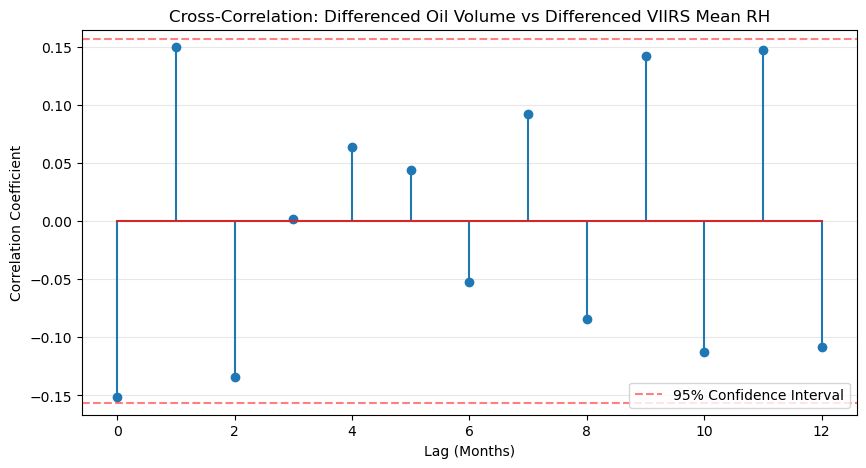

In [71]:
# =============================================================================
# 4. STATISTICAL VALIDATION FOR ARIMAX
# =============================================================================
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, ccf

target = prod_col  # 'Volume'

print("--------------------------------------------------")
print("1. STATIONARITY CHECKS (Augmented Dickey-Fuller)")
print("--------------------------------------------------")
def adf_test(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]
    
    print(f"[{name}] ADF p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  -> Stationary (d=0).")
    else:
        print(f"  -> NOT Stationary (Needs differencing, d=1).")
    return p_value

# Check the raw series
p_target = adf_test(df_ts[target], "Raw Oil Volume")
p_exo = adf_test(df_ts[exo_feature], "Raw VIIRS Mean RH")

# Difference the data to make it stationary for modeling tests
df_diff = df_ts.diff().dropna()

print("\n(Checking differenced data...)")
adf_test(df_diff[target], "Differenced Oil Volume")
adf_test(df_diff[exo_feature], "Differenced VIIRS Mean RH")


print("\n--------------------------------------------------")
print("2. GRANGER CAUSALITY TEST")
print("--------------------------------------------------")
print(f"H0: Past VIIRS values do NOT help forecast Oil Volume.")

# Testing up to 4 months of lags on the stationary series
try:
    gc_res = grangercausalitytests(df_diff[[target, exo_feature]], maxlag=4, verbose=True)
except Exception as e:
    print(f"Error running Granger test: {e}")


print("\n--------------------------------------------------")
print("3. CROSS-CORRELATION FUNCTION (CCF)")
print("--------------------------------------------------")
ccf_vals = ccf(df_diff[target], df_diff[exo_feature], adjusted=False)

plt.figure(figsize=(10, 5))
lags_to_plot = 12
plt.stem(range(lags_to_plot + 1), ccf_vals[:lags_to_plot + 1]) 

conf_int = 1.96 / np.sqrt(len(df_diff))
plt.axhline(conf_int, color='red', linestyle='--', alpha=0.5, label='95% Confidence Interval')
plt.axhline(-conf_int, color='red', linestyle='--', alpha=0.5)

plt.title('Cross-Correlation: Differenced Oil Volume vs Differenced VIIRS Mean RH')
plt.xlabel('Lag (Months)')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Training on 76 months: 2013-01-01 to 2019-04-01
Testing on 20 months: 2019-05-01 to 2020-12-01

Scaling exogenous variables to stabilize the solver...

Running Auto-ARIMA grid search on scaled data...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:               SARIMAX(3, 1, 2)   Log Likelihood                 -90.095
Date:                Tue, 07 Jul 2026   AIC                            194.190
Time:                        16:35:59   BIC                            210.412
Sample:                    01-01-2013   HQIC                           200.668
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
mea

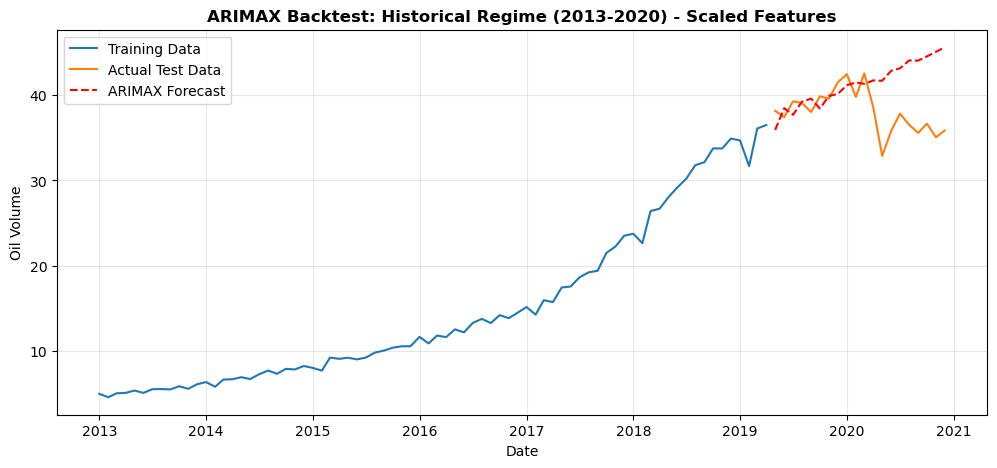

In [72]:
# =============================================================================
# 5. HISTORICAL BACKTEST (2013 - 2020) WITH SCALED FEATURES
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Convert Oil Volume to Millions of Barrels to stabilize the model variance
df_ts['Volume_MMbbl'] = df_ts['Volume'] / 1e6

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

target_col = 'Volume_MMbbl'
exo_cols = ['mean_rh_clear']

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# ---------------------------------------------------------
# Feature Scaling (Fixing the Condition Number Warning)
# ---------------------------------------------------------
print("\nScaling exogenous variables to stabilize the solver...")
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage, then transform
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)

# Transform the test data using the SAME scaler fitted on the training data
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 3. Fit the ARIMAX Model using Auto-ARIMA
print("\nRunning Auto-ARIMA grid search on scaled data...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,  # Pass the SCALED training features here
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, # Let the algorithm determine 'd' via ADF tests
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 4. Forecast the Test Set
# Pass the SCALED test features here
predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()
test_with_preds['Forecast'] = predictions

# 5. Evaluate and Plot
mape = mean_absolute_percentage_error(test_with_preds[target_col], test_with_preds['Forecast'])
print(f"\nMean Absolute Percentage Error (MAPE): {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train[target_col], label='Training Data')
plt.plot(test_with_preds.index, test_with_preds[target_col], label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Historical Regime (2013-2020) - Scaled Features', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training on 76 months: 2013-01-01 to 2019-04-01
Testing on 20 months: 2019-05-01 to 2020-12-01

Scaling exogenous variables...

Running Auto-ARIMA grid search (Optimizing for BIC)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 128.266
Date:                Tue, 07 Jul 2026   AIC                           -246.531
Time:                        16:36:00   BIC                           -234.944
Sample:                    01-01-2013   HQIC                          -241.904
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept         0.0

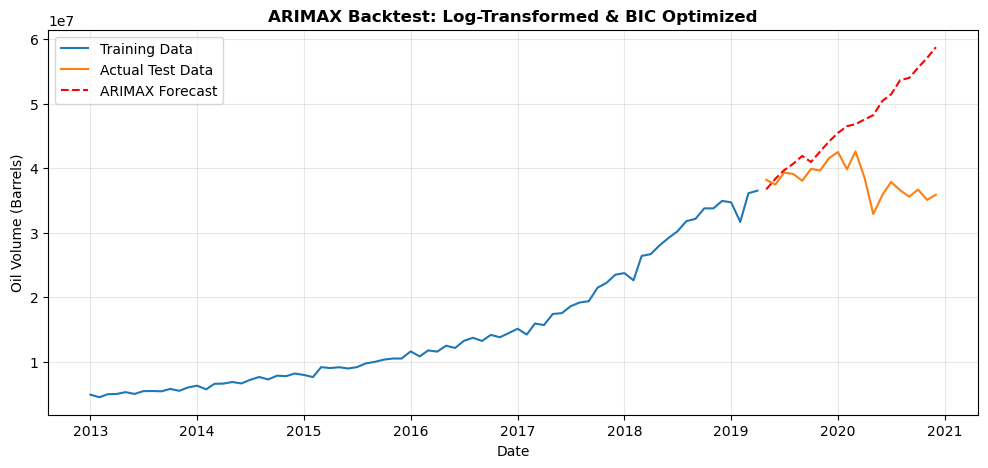

In [73]:
# =============================================================================
# 5. HISTORICAL BACKTEST (2013 - 2020) WITH LOG TRANSFORM & BIC PENALTY
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()

# -- NEW: Log Transformation --
# We take the natural log of the raw Volume to stabilize the exponential growth and variance
df_history['Log_Volume'] = np.log(df_history['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

# Target is now the Log-transformed volume
target_col = 'Log_Volume'
exo_cols = ['mean_rh_clear']

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# 3. Feature Scaling for Exogenous Variables
print("\nScaling exogenous variables...")
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 4. Fit the ARIMAX Model using Auto-ARIMA
# -- NEW: Set information_criterion to 'bic' to strongly penalize complex models --
print("\nRunning Auto-ARIMA grid search (Optimizing for BIC)...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, 
    seasonal=False,
    information_criterion='bic',  # Forces the solver to prefer simpler models
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 5. Forecast the Test Set
log_predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()

# -- NEW: Inverse the Log Transform --
# We use np.exp() to convert the log forecast back into standard Barrels
test_with_preds['Forecast_Volume'] = np.exp(log_predictions)
test_with_preds['Actual_Volume'] = test['Volume'] 

# 6. Evaluate and Plot on the original scale
mape = mean_absolute_percentage_error(test_with_preds['Actual_Volume'], test_with_preds['Forecast_Volume'])
print(f"\nMean Absolute Percentage Error (MAPE) on actual volume: {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Volume'], label='Training Data')
plt.plot(test_with_preds.index, test_with_preds['Actual_Volume'], label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast_Volume'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Log-Transformed & BIC Optimized', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Training on 76 months: 2013-01-01 to 2019-04-01
Testing on 20 months: 2019-05-01 to 2020-12-01

Scaling exogenous variables...

Running Auto-ARIMA grid search (Optimizing for BIC)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 127.643
Date:                Tue, 07 Jul 2026   AIC                           -245.286
Time:                        16:36:01   BIC                           -233.699
Sample:                    01-01-2013   HQIC                          -240.660
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept    

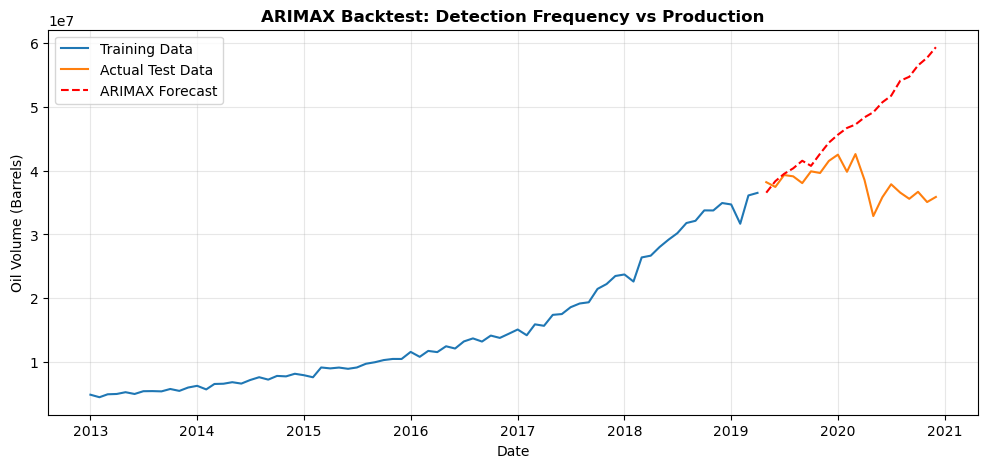

In [74]:
# =============================================================================
# 5. HISTORICAL BACKTEST: TESTING FLARING FREQUENCY
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()

# Log Transformation
df_history['Log_Volume'] = np.log(df_history['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

target_col = 'Log_Volume'
# -- CHANGED: Swapping intensity for frequency --
exo_cols = ['detect_freq_clear'] 

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# 3. Feature Scaling
print("\nScaling exogenous variables...")
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 4. Fit the ARIMAX Model using Auto-ARIMA
print("\nRunning Auto-ARIMA grid search (Optimizing for BIC)...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, 
    seasonal=False,
    information_criterion='bic',  
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 5. Forecast the Test Set
log_predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()

# Inverse the Log Transform
test_with_preds['Forecast_Volume'] = np.exp(log_predictions)
test_with_preds['Actual_Volume'] = test['Volume'] 

# 6. Evaluate and Plot
mape = mean_absolute_percentage_error(test_with_preds['Actual_Volume'], test_with_preds['Forecast_Volume'])
print(f"\nMean Absolute Percentage Error (MAPE) on actual volume: {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Volume'], label='Training Data')
plt.plot(test_with_preds.index, test_with_preds['Actual_Volume'], label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast_Volume'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Detection Frequency vs Production', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [75]:
# =============================================================================
# 6. MULTICOLLINEARITY CHECK (VIF)
# =============================================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a dataframe with just the variables we want to test
X_test = df_ts[['mean_rh_clear', 'detect_freq_clear']].dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_test.columns
vif_data["VIF"] = [variance_inflation_factor(X_test.values, i) for i in range(len(X_test.columns))]

print(vif_data)

             Feature        VIF
0      mean_rh_clear  34.968979
1  detect_freq_clear  34.968979


Training on 48 months: 2021-01-01 to 2024-12-01
Testing on 13 months: 2025-01-01 to 2026-01-01

Scaling exogenous variables...

Running Auto-ARIMA grid search (Optimizing for BIC)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   48
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  32.902
Date:                Tue, 07 Jul 2026   AIC                            -59.804
Time:                        16:36:01   BIC                            -54.253
Sample:                    01-01-2021   HQIC                           -57.715
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
detect_freq_c

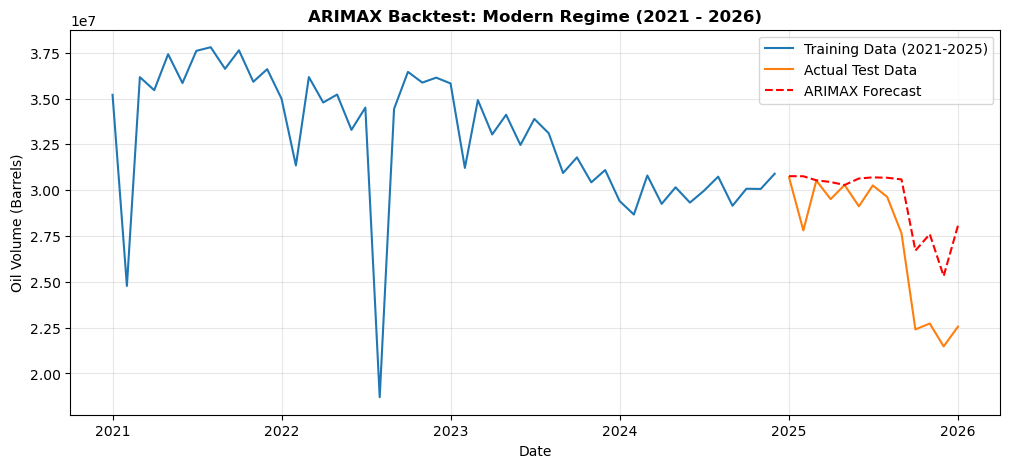

In [76]:
# =============================================================================
# 7. MODERN ERA BACKTEST (2021 - 2026): TESTING THE ESG / PIPELINE SHIFT
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the Modern Regime (Jan 2021 through Jan 2026)
df_modern = df_ts.loc['2021-01-01':'2026-01-01'].copy()

# Log Transformation for stable variance
df_modern['Log_Volume'] = np.log(df_modern['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_modern) * 0.8)
train = df_modern.iloc[:split_idx]
test = df_modern.iloc[split_idx:]

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear'] 

print(f"Training on {len(train)} months: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing on {len(test)} months: {test.index.min().date()} to {test.index.max().date()}")

# 3. Feature Scaling
print("\nScaling exogenous variables...")
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# 4. Fit the ARIMAX Model using Auto-ARIMA
print("\nRunning Auto-ARIMA grid search (Optimizing for BIC)...")
model = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=None, 
    seasonal=False,
    information_criterion='bic',  
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)
print(model.summary())

# 5. Forecast the Test Set
log_predictions = model.predict(n_periods=len(test), X=test_exo_scaled)
test_with_preds = test.copy()

# Inverse the Log Transform to get real Barrels
test_with_preds['Forecast_Volume'] = np.exp(log_predictions)
test_with_preds['Actual_Volume'] = test['Volume'] 

# 6. Evaluate and Plot
mape = mean_absolute_percentage_error(test_with_preds['Actual_Volume'], test_with_preds['Forecast_Volume'])
print(f"\nMean Absolute Percentage Error (MAPE) on actual volume: {mape:.2%}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Volume'], label='Training Data (2021-2025)')
plt.plot(test_with_preds.index, test_with_preds['Actual_Volume'], color='tab:orange', label='Actual Test Data')
plt.plot(test_with_preds.index, test_with_preds['Forecast_Volume'], color='red', linestyle='--', label='ARIMAX Forecast')
plt.title('ARIMAX Backtest: Modern Regime (2021 - 2026)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


--- Training Baseline ARIMA (No Satellite Data) ---
Baseline Model Selected: (0, 1, 2)

--- Training ARIMAX (With Satellite Data) ---
ARIMAX Model Selected: (0, 1, 2)

================ PERFORMANCE SUMMARY ================
Baseline ARIMA MAPE: 28.78%
ARIMAX MAPE:         25.49%
Improvement:         3.28% absolute percentage points


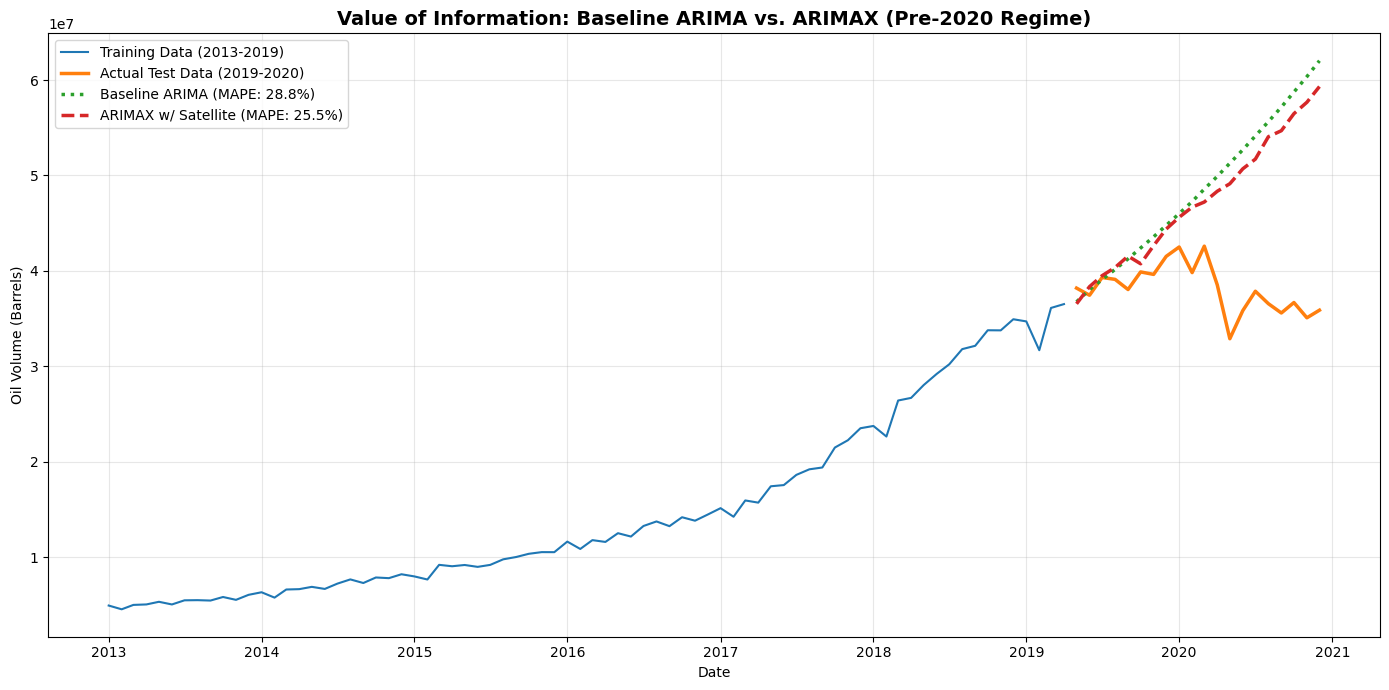

In [77]:
# =============================================================================
# 8. HEAD-TO-HEAD: BASELINE ARIMA vs. ARIMAX (Pre-2020 Regime)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the Historical Regime (2013 through 2020)
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

# 2. Sequential Train-Test Split (80/20)
split_idx = int(len(df_history) * 0.8)
train = df_history.iloc[:split_idx]
test = df_history.iloc[split_idx:]

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']

# 3. Feature Scaling for ARIMAX
scaler = StandardScaler()
train_exo_scaled = pd.DataFrame(
    scaler.fit_transform(train[exo_cols]), 
    columns=exo_cols, 
    index=train.index
)
test_exo_scaled = pd.DataFrame(
    scaler.transform(test[exo_cols]), 
    columns=exo_cols, 
    index=test.index
)

# ---------------------------------------------------------
# 4. Train the Baseline Model (ARIMA - NO Exogenous Data)
# ---------------------------------------------------------
print("\n--- Training Baseline ARIMA (No Satellite Data) ---")
model_baseline = pm.auto_arima(
    y=train[target_col], 
    start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', 
    stepwise=True, suppress_warnings=True, error_action="ignore"
)
print(f"Baseline Model Selected: {model_baseline.order}")

# ---------------------------------------------------------
# 5. Train the ARIMAX Model (WITH Satellite Data)
# ---------------------------------------------------------
print("\n--- Training ARIMAX (With Satellite Data) ---")
model_arimax = pm.auto_arima(
    y=train[target_col], 
    X=train_exo_scaled,
    start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', 
    stepwise=True, suppress_warnings=True, error_action="ignore"
)
print(f"ARIMAX Model Selected: {model_arimax.order}")

# ---------------------------------------------------------
# 6. Generate Forecasts & Inverse Log Transform
# ---------------------------------------------------------
# Baseline prediction (requires no X)
preds_baseline_log = model_baseline.predict(n_periods=len(test))
forecast_baseline = np.exp(preds_baseline_log)

# ARIMAX prediction (requires scaled X)
preds_arimax_log = model_arimax.predict(n_periods=len(test), X=test_exo_scaled)
forecast_arimax = np.exp(preds_arimax_log)

test_actual = test['Volume']

# ---------------------------------------------------------
# 7. Evaluate Metrics
# ---------------------------------------------------------
mape_baseline = mean_absolute_percentage_error(test_actual, forecast_baseline)
mape_arimax = mean_absolute_percentage_error(test_actual, forecast_arimax)

print(f"\n================ PERFORMANCE SUMMARY ================")
print(f"Baseline ARIMA MAPE: {mape_baseline:.2%}")
print(f"ARIMAX MAPE:         {mape_arimax:.2%}")
print(f"Improvement:         {mape_baseline - mape_arimax:.2%} absolute percentage points")
print("=====================================================")

# ---------------------------------------------------------
# 8. Visual Comparison
# ---------------------------------------------------------
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(train.index, train['Volume'], color='tab:blue', label='Training Data (2013-2019)')

# Plot actual test data
plt.plot(test.index, test_actual, color='tab:orange', linewidth=2.5, label='Actual Test Data (2019-2020)')

# Plot forecasts
plt.plot(test.index, forecast_baseline, color='tab:green', linestyle=':', linewidth=2.5, 
         label=f'Baseline ARIMA (MAPE: {mape_baseline:.1%})')
plt.plot(test.index, forecast_arimax, color='tab:red', linestyle='--', linewidth=2.5, 
         label=f'ARIMAX w/ Satellite (MAPE: {mape_arimax:.1%})')

plt.title('Value of Information: Baseline ARIMA vs. ARIMAX (Pre-2020 Regime)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Starting Robustness Test across multiple splits...

--- Processing 60/40 Split ---
Selected Model: (1, 1, 1)
MAPE: 43.63%

--- Processing 70/30 Split ---
Selected Model: (0, 1, 2)
MAPE: 28.37%

--- Processing 80/20 Split ---
Selected Model: (0, 1, 2)
MAPE: 25.49%



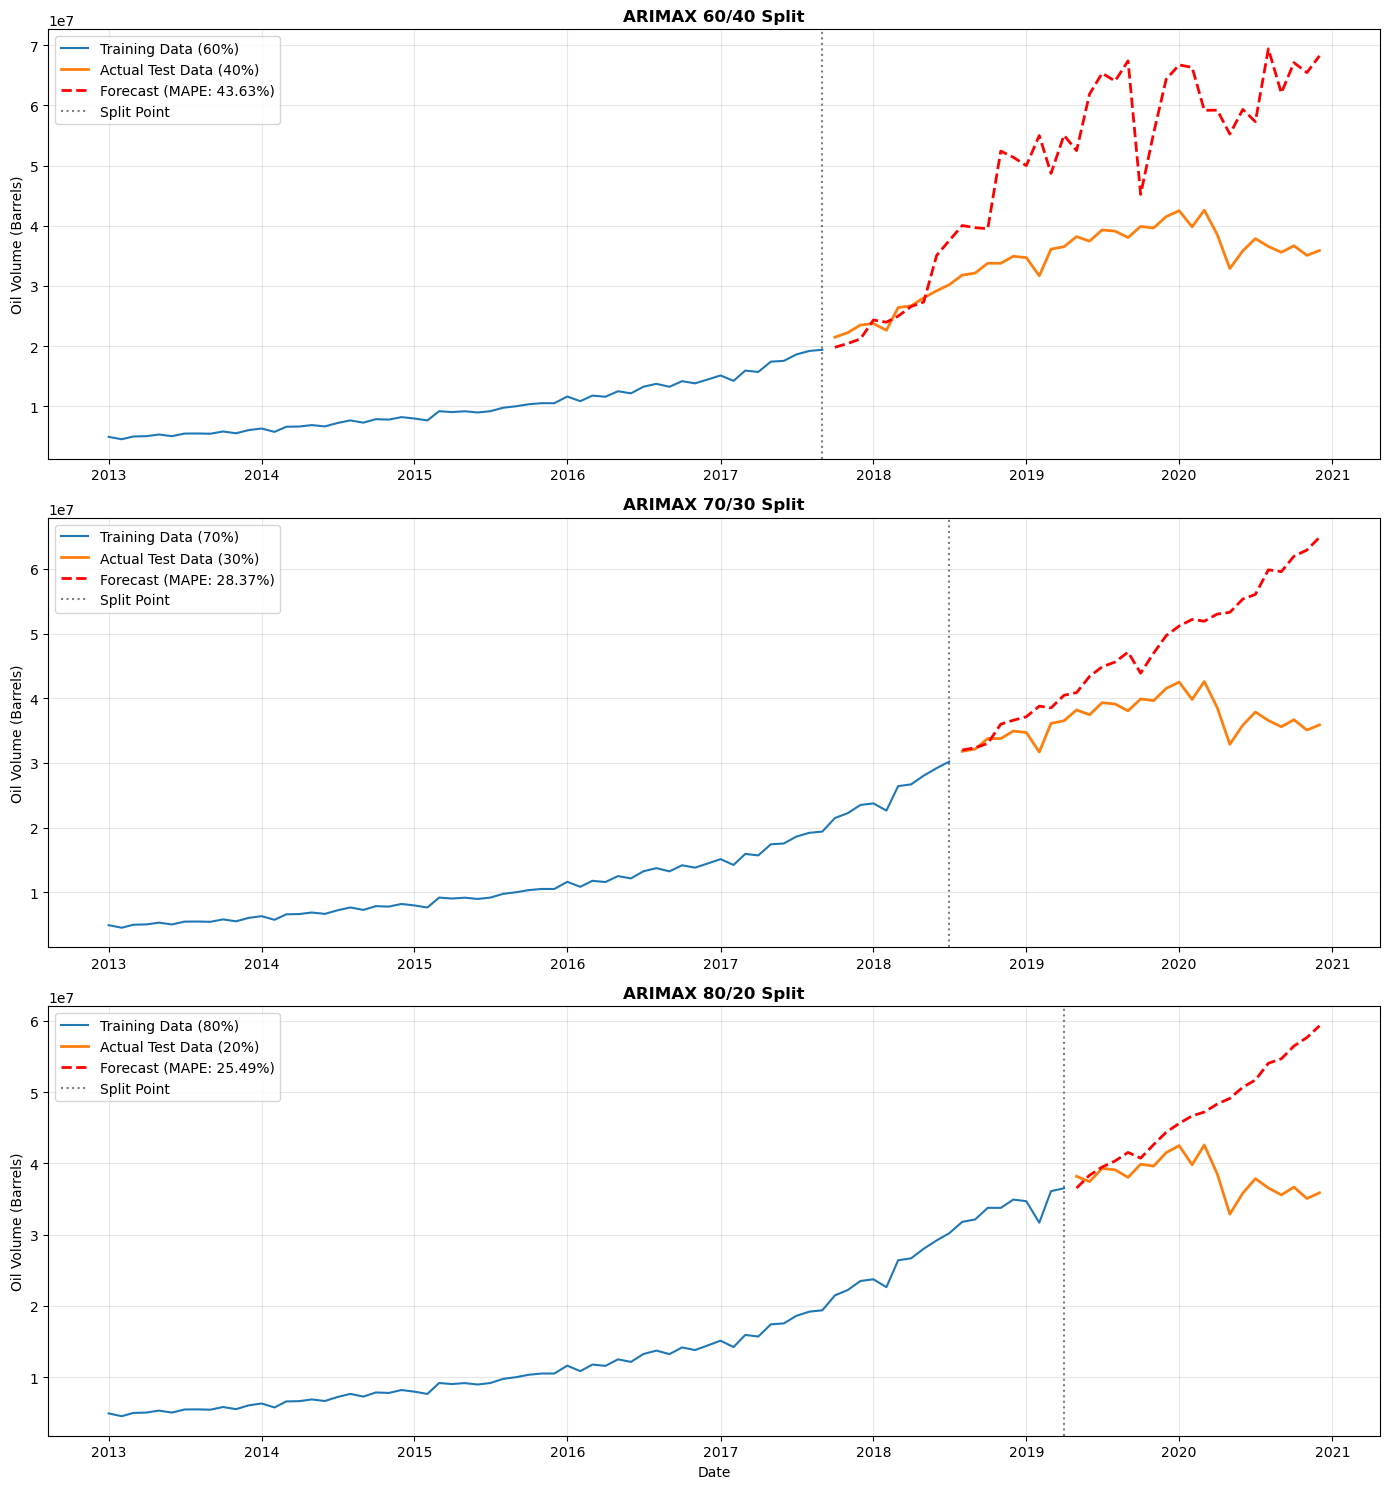

In [78]:
# =============================================================================
# 9. ROBUSTNESS TEST: MULTIPLE TRAIN-TEST SPLITS (Pre-2020 Regime)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Isolate the Historical Regime and Apply Log Transform
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']
split_ratios = [0.6, 0.7, 0.8]

# Set up a grid of subplots for visual comparison
fig, axes = plt.subplots(len(split_ratios), 1, figsize=(14, 15), sharex=False)

print("Starting Robustness Test across multiple splits...\n")

for i, split_ratio in enumerate(split_ratios):
    train_pct = int(split_ratio * 100)
    test_pct = 100 - train_pct
    print(f"--- Processing {train_pct}/{test_pct} Split ---")
    
    # 2. Sequential Train-Test Split
    split_idx = int(len(df_history) * split_ratio)
    train = df_history.iloc[:split_idx]
    test = df_history.iloc[split_idx:]
    
    # 3. Feature Scaling (Fit on Train, Transform Both)
    scaler = StandardScaler()
    train_exo_scaled = pd.DataFrame(
        scaler.fit_transform(train[exo_cols]), 
        columns=exo_cols, index=train.index
    )
    test_exo_scaled = pd.DataFrame(
        scaler.transform(test[exo_cols]), 
        columns=exo_cols, index=test.index
    )
    
    # 4. Train ARIMAX (Optimizing for BIC)
    model = pm.auto_arima(
        y=train[target_col], X=train_exo_scaled,
        start_p=0, start_q=0, max_p=3, max_q=3,
        d=None, seasonal=False, information_criterion='bic', 
        stepwise=True, suppress_warnings=True, error_action="ignore"
    )
    
    # 5. Forecast and Inverse Log Transform
    preds_log = model.predict(n_periods=len(test), X=test_exo_scaled)
    forecast_vol = np.exp(preds_log)
    test_actual = test['Volume']
    
    # 6. Evaluate
    mape = mean_absolute_percentage_error(test_actual, forecast_vol)
    print(f"Selected Model: {model.order}")
    print(f"MAPE: {mape:.2%}\n")
    
    # 7. Plotting on the respective subplot
    ax = axes[i]
    ax.plot(train.index, train['Volume'], color='tab:blue', label=f'Training Data ({train_pct}%)')
    ax.plot(test.index, test_actual, color='tab:orange', linewidth=2, label=f'Actual Test Data ({test_pct}%)')
    ax.plot(test.index, forecast_vol, color='red', linestyle='--', linewidth=2, label=f'Forecast (MAPE: {mape:.2%})')
    
    # Visual divider for the split point
    ax.axvline(x=train.index[-1], color='black', linestyle=':', alpha=0.5, label='Split Point')
    
    ax.set_title(f'ARIMAX {train_pct}/{test_pct} Split', fontweight='bold')
    ax.set_ylabel('Oil Volume (Barrels)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

Initial Training Window: 2013-01-01 to 2016-12-01
Starting 1-step ahead forecasts from: 2017-01-01 to 2020-12-01

Training Initial Baseline ARIMA...
Training Initial ARIMAX...

Running Walk-Forward Loop (Month by Month)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 121.305
Date:                Tue, 07 Jul 2026   AIC                           -232.610
Time:                        16:36:08   BIC                           -219.841
Sample:                             0   HQIC                          -227.450
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

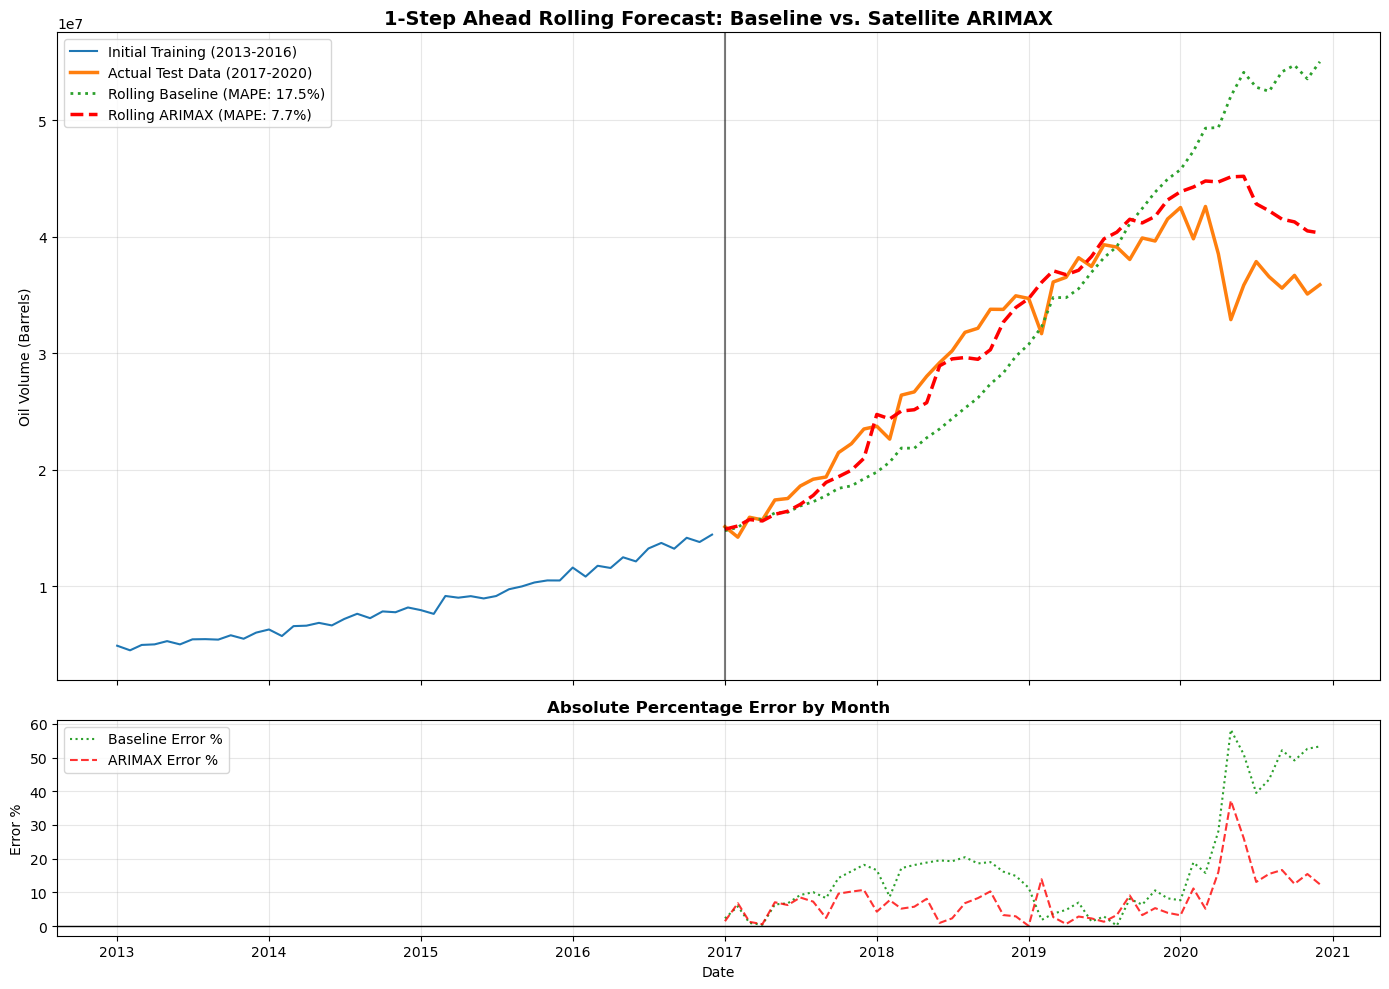

In [79]:
# =============================================================================
# 10. REAL-WORLD SIMULATION: WALK-FORWARD VALIDATION (1-Step Ahead)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data up to 2020
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']

# 2. Define the exact date you "start" using the model
start_date = pd.to_datetime('2017-01-01')

# The initial training data (everything before 2017)
train_initial = df_history[df_history.index < start_date]
# The months we will loop through and predict one by one
test_dates = df_history[df_history.index >= start_date].index

print(f"Initial Training Window: {train_initial.index.min().date()} to {train_initial.index.max().date()}")
print(f"Starting 1-step ahead forecasts from: {start_date.date()} to {test_dates.max().date()}\n")

# 3. Initialize Scaler and Models on the Initial 2013-2016 Data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

# Lists to store our monthly predictions
preds_baseline = []
preds_arimax = []
actual_volumes = []
arimax_absolute_errors = []
baseline_absolute_errors = []

# Keep a running dataframe of "observed" data to continuously refit the scaler
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")

# 4. The Time Machine Loop
for date in test_dates:
    # A. Get the satellite data (X) and actual volume (y) for this specific month
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    # B. Scale the incoming satellite data using what we know UP TO THIS POINT
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # C. FORECAST 1 MONTH AHEAD
    # Wrap the output in np.array() so standard indexing [0] works perfectly for both Series and Arrays
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    # Inverse log transform and store
    vol_base = np.exp(pred_base_log)
    vol_arimax = np.exp(pred_arimax_log)
    
    preds_baseline.append(vol_base)
    preds_arimax.append(vol_arimax)
    actual_volumes.append(actual_vol)
    
    # Track errors for visualization
    baseline_absolute_errors.append(abs(vol_base - actual_vol) / actual_vol)
    arimax_absolute_errors.append(abs(vol_arimax - actual_vol) / actual_vol)
    
    # D. OBSERVE REPORTED DATA & UPDATE MODELS
    # The official production report drops, so we feed it into the models to update their math
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    # Add this month to our running training data and update the scaler for next month
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 5. Evaluate Overall Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(model_arimax.summary())
print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE: {mape_base:.2%}")
print(f"ARIMAX MAPE:         {mape_arimax:.2%}")
print("============================================================")

# 6. Visualization: Forecast vs Actuals & Error tracking over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top Plot: Forecasts
ax1.plot(train_initial.index, train_initial['Volume'], color='tab:blue', label='Initial Training (2013-2016)')
ax1.plot(test_dates, actual_volumes, color='tab:orange', linewidth=2.5, label='Actual Test Data (2017-2020)')
ax1.plot(test_dates, preds_baseline, color='tab:green', linestyle=':', linewidth=2, label=f'Rolling Baseline (MAPE: {mape_base:.1%})')
ax1.plot(test_dates, preds_arimax, color='red', linestyle='--', linewidth=2.5, label=f'Rolling ARIMAX (MAPE: {mape_arimax:.1%})')

ax1.axvline(x=start_date, color='black', linestyle='-', alpha=0.5)
ax1.set_title('1-Step Ahead Rolling Forecast: Baseline vs. Satellite ARIMAX', fontsize=14, fontweight='bold')
ax1.set_ylabel('Oil Volume (Barrels)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Bottom Plot: Percentage Error over time
ax2.plot(test_dates, np.array(baseline_absolute_errors)*100, color='tab:green', linestyle=':', label='Baseline Error %')
ax2.plot(test_dates, np.array(arimax_absolute_errors)*100, color='red', linestyle='--', alpha=0.8, label='ARIMAX Error %')
ax2.set_title('Absolute Percentage Error by Month', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error %')
ax2.axhline(y=0, color='black', linewidth=1)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Initial Training Window: 2013-01-01 to 2022-11-01
Starting 1-step ahead forecasts from: 2022-12-01 to 2024-12-01

Training Initial Baseline ARIMA...
Training Initial ARIMAX...

Running Walk-Forward Loop (Month by Month)...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 143.273
Date:                Tue, 07 Jul 2026   AIC                           -278.546
Time:                        16:44:01   BIC                           -266.694
Sample:                             0   HQIC                          -273.730
                                - 144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

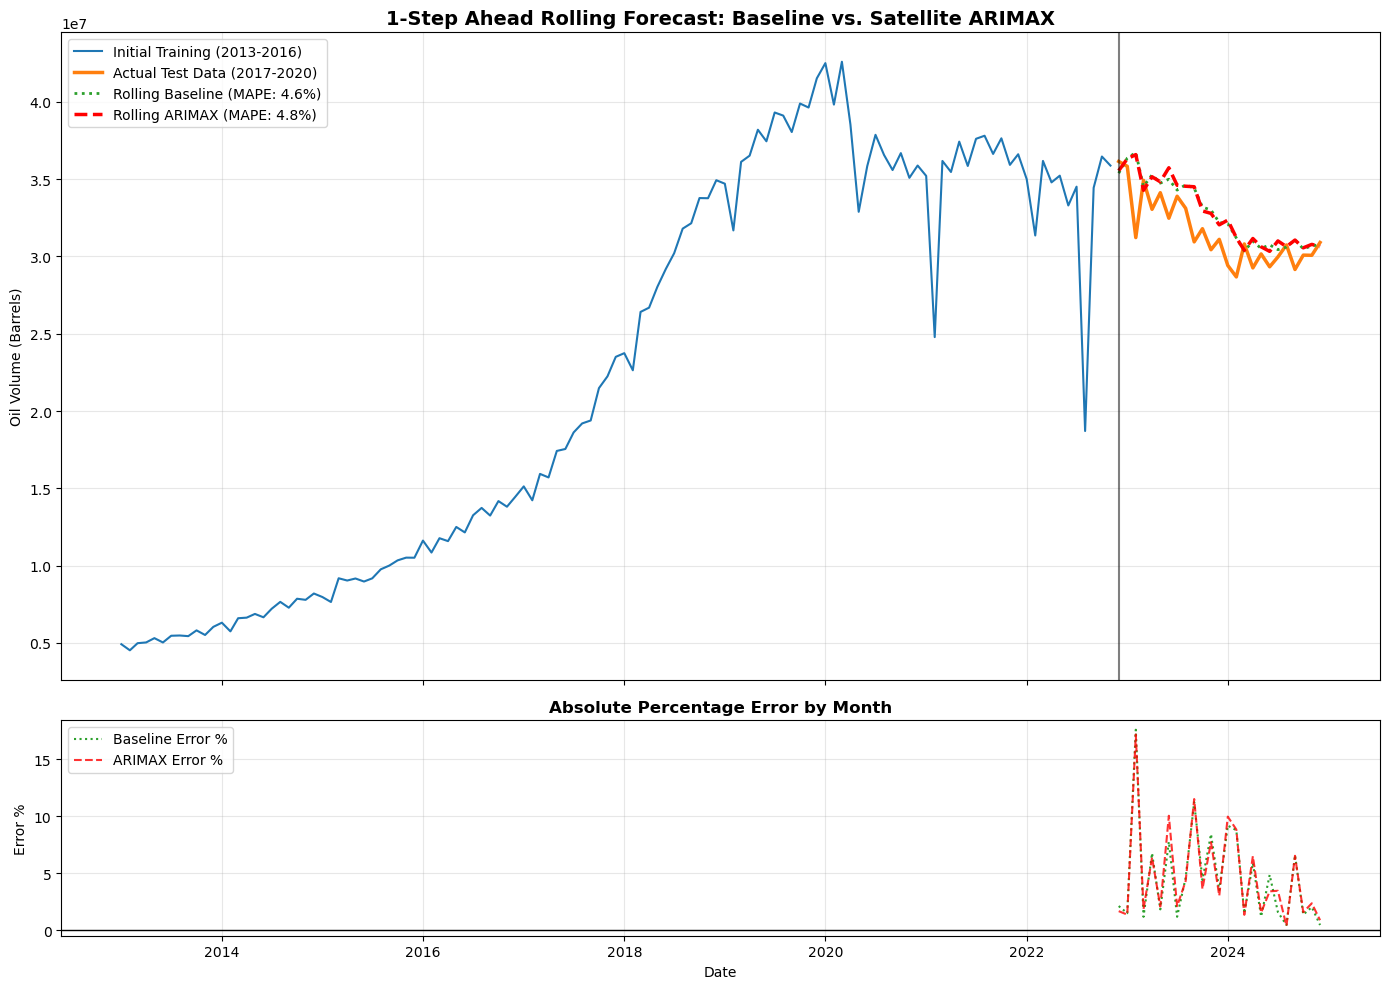

In [83]:
# =============================================================================
# 10. REAL-WORLD SIMULATION: WALK-FORWARD VALIDATION (1-Step Ahead)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data up to 2020
df_history = df_ts.loc[:'2024-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
exo_cols = ['detect_freq_clear']

# 2. Define the exact date you "start" using the model
start_date = pd.to_datetime('2022-12-01')

# The initial training data (everything before 2017)
train_initial = df_history[df_history.index < start_date]
# The months we will loop through and predict one by one
test_dates = df_history[df_history.index >= start_date].index

print(f"Initial Training Window: {train_initial.index.min().date()} to {train_initial.index.max().date()}")
print(f"Starting 1-step ahead forecasts from: {start_date.date()} to {test_dates.max().date()}\n")

# 3. Initialize Scaler and Models on the Initial 2013-2016 Data
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

# Lists to store our monthly predictions
preds_baseline = []
preds_arimax = []
actual_volumes = []
arimax_absolute_errors = []
baseline_absolute_errors = []

# Keep a running dataframe of "observed" data to continuously refit the scaler
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")

# 4. The Time Machine Loop
for date in test_dates:
    # A. Get the satellite data (X) and actual volume (y) for this specific month
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    # B. Scale the incoming satellite data using what we know UP TO THIS POINT
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # C. FORECAST 1 MONTH AHEAD
    # Wrap the output in np.array() so standard indexing [0] works perfectly for both Series and Arrays
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    # Inverse log transform and store
    vol_base = np.exp(pred_base_log)
    vol_arimax = np.exp(pred_arimax_log)
    
    preds_baseline.append(vol_base)
    preds_arimax.append(vol_arimax)
    actual_volumes.append(actual_vol)
    
    # Track errors for visualization
    baseline_absolute_errors.append(abs(vol_base - actual_vol) / actual_vol)
    arimax_absolute_errors.append(abs(vol_arimax - actual_vol) / actual_vol)
    
    # D. OBSERVE REPORTED DATA & UPDATE MODELS
    # The official production report drops, so we feed it into the models to update their math
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    # Add this month to our running training data and update the scaler for next month
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 5. Evaluate Overall Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(model_arimax.summary())
print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE: {mape_base:.2%}")
print(f"ARIMAX MAPE:         {mape_arimax:.2%}")
print("============================================================")

# 6. Visualization: Forecast vs Actuals & Error tracking over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top Plot: Forecasts
ax1.plot(train_initial.index, train_initial['Volume'], color='tab:blue', label='Initial Training (2013-2016)')
ax1.plot(test_dates, actual_volumes, color='tab:orange', linewidth=2.5, label='Actual Test Data (2017-2020)')
ax1.plot(test_dates, preds_baseline, color='tab:green', linestyle=':', linewidth=2, label=f'Rolling Baseline (MAPE: {mape_base:.1%})')
ax1.plot(test_dates, preds_arimax, color='red', linestyle='--', linewidth=2.5, label=f'Rolling ARIMAX (MAPE: {mape_arimax:.1%})')

ax1.axvline(x=start_date, color='black', linestyle='-', alpha=0.5)
ax1.set_title('1-Step Ahead Rolling Forecast: Baseline vs. Satellite ARIMAX', fontsize=14, fontweight='bold')
ax1.set_ylabel('Oil Volume (Barrels)')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# Bottom Plot: Percentage Error over time
ax2.plot(test_dates, np.array(baseline_absolute_errors)*100, color='tab:green', linestyle=':', label='Baseline Error %')
ax2.plot(test_dates, np.array(arimax_absolute_errors)*100, color='red', linestyle='--', alpha=0.8, label='ARIMAX Error %')
ax2.set_title('Absolute Percentage Error by Month', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error %')
ax2.axhline(y=0, color='black', linewidth=1)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# =============================================================================
# 11. WALK-FORWARD VALIDATION: ROLLING AVERAGE FIX (2013-2020)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data & Engineer Rolling Feature
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

# -- NEW: 3-Month Rolling Average of Detection Frequency --
df_history['detect_freq_roll3'] = df_history['detect_freq_clear'].rolling(window=3, min_periods=1).mean()

target_col = 'Log_Volume'
exo_cols = ['detect_freq_roll3']  # Using the smoothed feature

# 2. Define simulation start
start_date = pd.to_datetime('2017-01-01')
train_initial = df_history[df_history.index < start_date]
test_dates = df_history[df_history.index >= start_date].index

# 3. Initialize Scaler and Models
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX (with 3-Month Smoothed Satellite Data)...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

preds_baseline, preds_arimax, actual_volumes = [], [], []
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")
for date in test_dates:
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # Forecast 1 step ahead (wrapping in np.array for version safety)
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    preds_baseline.append(np.exp(pred_base_log))
    preds_arimax.append(np.exp(pred_arimax_log))
    actual_volumes.append(actual_vol)
    
    # Update models with reported data
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 4. Evaluate Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE: {mape_base:.2%}")
print(f"Smoothed ARIMAX MAPE: {mape_arimax:.2%}")
if mape_arimax < mape_base:
    print(f"SUCCESS: Smoothed Satellite Data improved accuracy by {mape_base - mape_arimax:.2%}!")
else:
    print("Satellite data still underperformed the baseline in a 1-step scenario.")
print("============================================================")

Training Initial Baseline ARIMA...
Training Initial ARIMAX (with 3-Month Smoothed Satellite Data)...

Running Walk-Forward Loop (Month by Month)...

================ ROLLING 1-STEP PERFORMANCE ================
Baseline ARIMA MAPE: 17.54%
Smoothed ARIMAX MAPE: 5.16%
SUCCESS: Smoothed Satellite Data improved accuracy by 12.38%!


In [60]:
df_viirs_filtered.columns

Index(['site_id', 'date', 'oil_pipeline_bbl', 'oil_truck_bbl',
       'oil_tankcar_bbl', 'oil_tank_cleaning_bbl', 'oil_circulating_bbl',
       'oil_lost_stolen_bbl', 'oil_bsw_repressure_bbl', 'oil_legacy_bbl',
       'oil_skimmed_bbl', 'oil_scrubber_bbl', 'oil_no_disp_code_bbl',
       'csgd_field_ops_fuel_mcf', 'csgd_transmission_mcf',
       'csgd_processing_plant_mcf', 'csgd_vented_flared_mcf',
       'csgd_gas_lift_mcf', 'csgd_repressure_mcf', 'csgd_carbon_black_mcf',
       'csgd_underground_storage_mcf', 'csgd_no_disp_code_mcf',
       'oil_sold_total_bbl', 'total_vented_flared_mcf', 'year_month', 'Year',
       'Month', 'lat', 'lon', 'n_obs', 'n_detect', 'n_nondet', 'n_detect_cm0',
       'n_nondet_cm0', 'n_detect_cm1', 'n_nondet_cm1', 'n_detect_cm2',
       'n_nondet_cm2', 'n_detect_cm3', 'n_nondet_cm3', 'n_detect_cmNA',
       'n_nondet_cmNA', 'n_obs_SNPP', 'n_detect_SNPP', 'n_obs_NOAA20',
       'n_detect_NOAA20', 'n_obs_OTHERSAT', 'n_detect_OTHERSAT', 'rh_sum',
       'rh_n

In [61]:
# =============================================================================
# 12. FEATURE ENGINEERING: SITE-LEVEL ANOMALIES (Z-SCORES)
# =============================================================================

print("Calculating Site-Level rolling anomalies...")

# 1. Start with the geographically filtered site-level VIIRS data
df_site = df_viirs_filtered.copy()

# Calculate the frequency per site per month
# (Adding a tiny epsilon 1e-9 to prevent division by zero)
df_site['site_freq'] = df_site['total_detects'] / (df_site['total_obs'] + 1e-9)

# 2. Sort by Site and Date to ensure rolling windows work correctly
#df_site['Date'] = pd.to_datetime(df_site[['Year', 'Month']].assign(DAY=1))
df_site = df_site.sort_values(by=['site_id', 'date'])

# 3. Calculate 6-month rolling mean and standard deviation PER SITE
df_site['rolling_mean_6m'] = df_site.groupby('site_id')['site_freq'].transform(
    lambda x: x.rolling(window=6, min_periods=3).mean()
)
df_site['rolling_std_6m'] = df_site.groupby('site_id')['site_freq'].transform(
    lambda x: x.rolling(window=6, min_periods=3).std()
)

# 4. Calculate the Z-Score Anomaly 
# (How many standard deviations is this month's flaring away from the site's recent norm?)
df_site['site_anomaly_zscore'] = (df_site['site_freq'] - df_site['rolling_mean_6m']) / (df_site['rolling_std_6m'] + 1e-9)

# 5. Define an "Anomalous Event" as a Z-score > 2.0
df_site['is_high_anomaly'] = (df_site['site_anomaly_zscore'] > 2.0).astype(int)

# 6. Aggregate back to the Basin level (Time Series)
# We count how many sites experienced a massive flaring anomaly in that month
anomaly_ts = df_site.groupby('date')['is_high_anomaly'].sum().reset_index()
anomaly_ts.rename(columns={'is_high_anomaly': 'anomalous_site_count'}, inplace=True)
anomaly_ts.set_index('date', inplace=True)

# Merge this powerful new feature back into our main time series dataframe
df_ts = pd.merge(df_ts, anomaly_ts, left_index=True, right_index=True, how='left')
# Fill NaNs with 0 (since the first few months won't have a 6-month rolling history)
df_ts['anomalous_site_count'] = df_ts['anomalous_site_count'].fillna(0)

print("Engineered 'anomalous_site_count' successfully.")
display(df_ts[['Volume', 'detect_freq_clear', 'anomalous_site_count']].tail(10))

Calculating Site-Level rolling anomalies...
Engineered 'anomalous_site_count' successfully.


,Volume,detect_freq_clear,anomalous_site_count
year_month,,,
2025-04-01 00:00:00,2.951313e+07,0.065887,0.0
2025-05-01 00:00:00,3.028411e+07,0.071749,0.0
2025-06-01 00:00:00,2.912145e+07,0.059063,0.0
2025-07-01 00:00:00,3.026179e+07,0.056901,0.0
2025-08-01 00:00:00,2.963655e+07,0.057606,0.0
2025-09-01 00:00:00,2.764786e+07,0.060925,0.0
2025-10-01 00:00:00,2.240472e+07,0.208611,0.0
2025-11-01 00:00:00,2.272746e+07,0.172638,0.0
2025-12-01 00:00:00,2.147763e+07,0.266794,0.0


Running XGBoost Walk-Forward Validation from 2017-01-01 to 2026-01-01...

================ XGBOOST PERFORMANCE ================
XGBoost MAPE (2017-2026): 8.37%


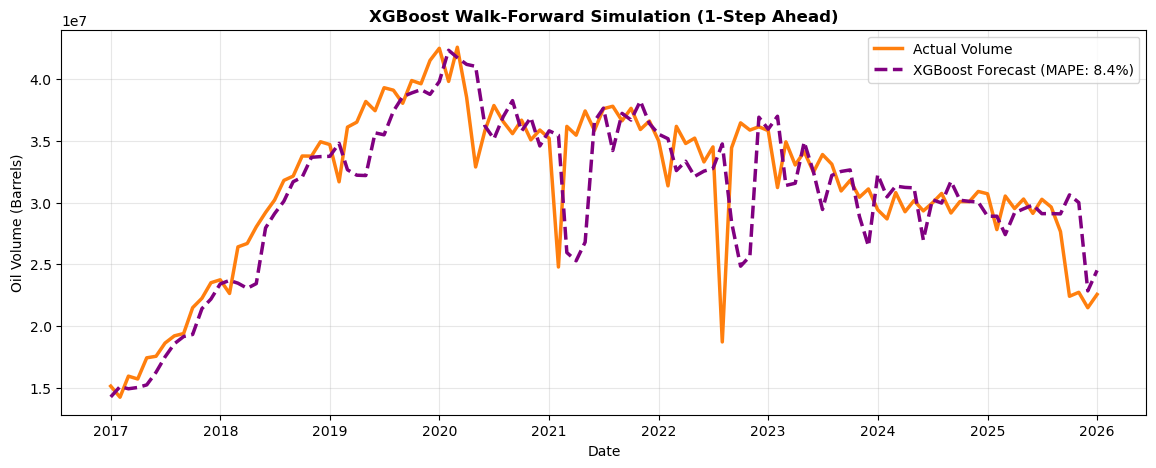

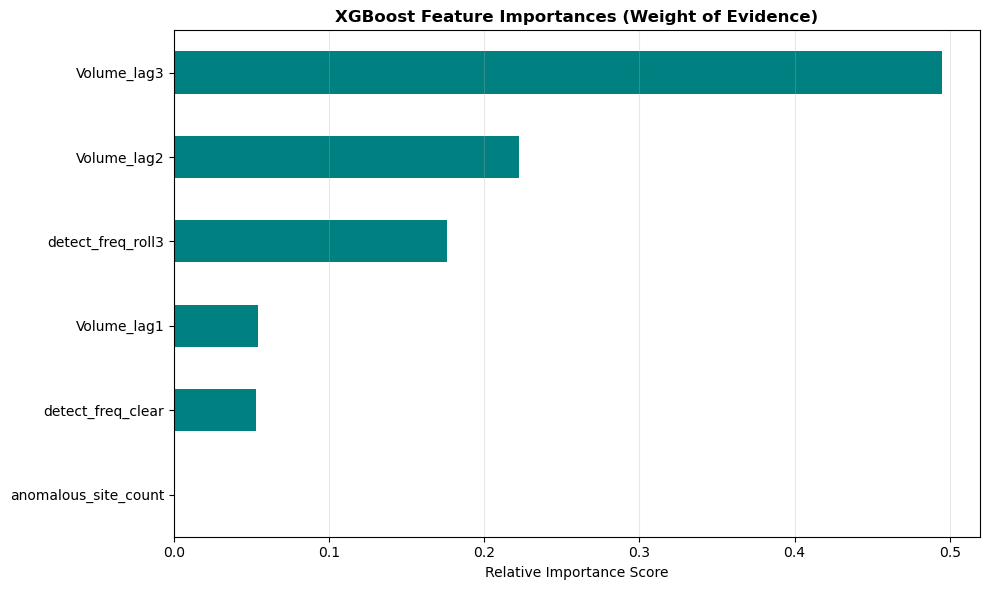

In [62]:
# =============================================================================
# 13. NON-LINEAR ML: XGBOOST WALK-FORWARD VALIDATION
# =============================================================================
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create a Supervised Learning DataFrame
# We select our target, our concurrent satellite features, and our new anomaly feature
df_xgb = df_ts[['Volume', 'detect_freq_clear', 'anomalous_site_count']].copy()

# Ensure we have the rolling average feature (in case it wasn't carried over)
df_xgb['detect_freq_roll3'] = df_xgb['detect_freq_clear'].rolling(window=3, min_periods=1).mean()

# 2. Engineer Lagged Target Features (The "Momentum")
# We feed the model exactly what oil production was 1, 2, and 3 months ago
df_xgb['Volume_lag1'] = df_xgb['Volume'].shift(1)
df_xgb['Volume_lag2'] = df_xgb['Volume'].shift(2)
df_xgb['Volume_lag3'] = df_xgb['Volume'].shift(3)

# Drop the first 3 rows which now have NaNs due to the shifting
df_xgb = df_xgb.dropna()

# 3. Define the Machine Learning Inputs
# Notice we are NOT scaling the data. XGBoost is tree-based and immune to scale variance!
features = [
    'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 
    'detect_freq_clear', 'detect_freq_roll3', 'anomalous_site_count'
]
target = 'Volume'

# 4. Set up the Walk-Forward Loop (2017 to 2026)
start_date = pd.to_datetime('2017-01-01')
test_dates = df_xgb[df_xgb.index >= start_date].index

preds_xgb = []
actuals_xgb = []

print(f"Running XGBoost Walk-Forward Validation from {start_date.date()} to {test_dates.max().date()}...")

# 5. The Time Machine Loop
for date in test_dates:
    # A. Split data into "Past" (Training) and "Present" (Testing)
    train = df_xgb[df_xgb.index < date]
    test = df_xgb[df_xgb.index == date]
    
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]
    
    # B. Train the XGBoost Model
    # We keep max_depth shallow (3) to prevent overfitting on our small dataset
    model_xgb = xgb.XGBRegressor(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1, 
        objective='reg:squarederror',
        random_state=42
    )
    model_xgb.fit(X_train, y_train)
    
    # C. Predict the current month
    pred = model_xgb.predict(X_test)[0]
    
    preds_xgb.append(pred)
    actuals_xgb.append(y_test.iloc[0])

# 6. Evaluate Performance
mape_xgb = mean_absolute_percentage_error(actuals_xgb, preds_xgb)

print(f"\n================ XGBOOST PERFORMANCE ================")
print(f"XGBoost MAPE (2017-2026): {mape_xgb:.2%}")
print("=====================================================")

# 7. Visualization: Forecast vs Actuals
plt.figure(figsize=(14, 5))
plt.plot(test_dates, actuals_xgb, color='tab:orange', linewidth=2.5, label='Actual Volume')
plt.plot(test_dates, preds_xgb, color='purple', linestyle='--', linewidth=2.5, label=f'XGBoost Forecast (MAPE: {mape_xgb:.1%})')
plt.title('XGBoost Walk-Forward Simulation (1-Step Ahead)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Oil Volume (Barrels)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 8. Visualization: What features actually mattered?
plt.figure(figsize=(10, 6))
# Get feature importances from the final model trained in the loop
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importances (Weight of Evidence)', fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Running XGBoost Walk-Forward Validation (Pre-2020 Regime: 2017-01-01 to 2020-12-01)...

================ PRE-2020 XGBOOST PERFORMANCE ================
XGBoost MAPE (2017-2020): 6.21%


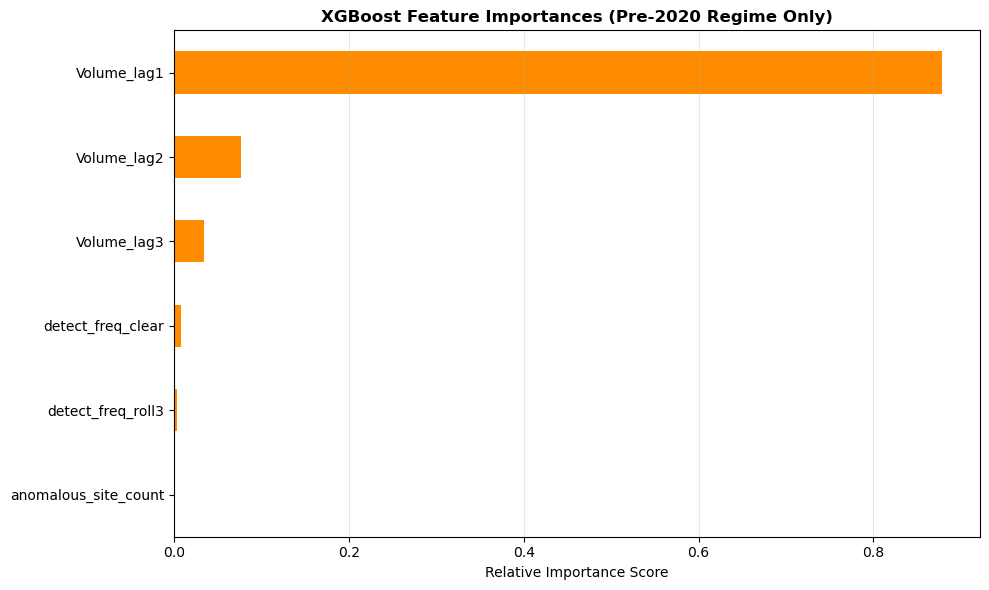

In [63]:
# =============================================================================
# 14. XGBOOST WALK-FORWARD: PRE-2020 REGIME TEST
# =============================================================================
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Prepare Data and Lags (Same as before)
df_xgb = df_ts[['Volume', 'detect_freq_clear', 'anomalous_site_count']].copy()
df_xgb['detect_freq_roll3'] = df_xgb['detect_freq_clear'].rolling(window=3, min_periods=1).mean()

df_xgb['Volume_lag1'] = df_xgb['Volume'].shift(1)
df_xgb['Volume_lag2'] = df_xgb['Volume'].shift(2)
df_xgb['Volume_lag3'] = df_xgb['Volume'].shift(3)
df_xgb = df_xgb.dropna()

features = [
    'Volume_lag1', 'Volume_lag2', 'Volume_lag3', 
    'detect_freq_clear', 'detect_freq_roll3', 'anomalous_site_count'
]
target = 'Volume'

# 2. CONSTRAIN THE TIMELINE TO THE HISTORICAL REGIME
# We stop the simulation at December 2020
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2020-12-01')
test_dates = df_xgb[(df_xgb.index >= start_date) & (df_xgb.index <= end_date)].index

preds_xgb = []
actuals_xgb = []

print(f"Running XGBoost Walk-Forward Validation (Pre-2020 Regime: {start_date.date()} to {test_dates.max().date()})...")

for date in test_dates:
    train = df_xgb[df_xgb.index < date]
    test = df_xgb[df_xgb.index == date]
    
    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]
    
    model_xgb = xgb.XGBRegressor(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1, 
        objective='reg:squarederror',
        random_state=42
    )
    model_xgb.fit(X_train, y_train)
    pred = model_xgb.predict(X_test)[0]
    
    preds_xgb.append(pred)
    actuals_xgb.append(y_test.iloc[0])

# 3. Evaluate Performance
mape_xgb = mean_absolute_percentage_error(actuals_xgb, preds_xgb)

print(f"\n================ PRE-2020 XGBOOST PERFORMANCE ================")
print(f"XGBoost MAPE (2017-2020): {mape_xgb:.2%}")
print("==============================================================")

# 4. Feature Importance for the Historical Regime
plt.figure(figsize=(10, 6))
importances = pd.Series(model_xgb.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='darkorange')
plt.title('XGBoost Feature Importances (Pre-2020 Regime Only)', fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# =============================================================================
# 15. EXTRACTING HIDDEN PHYSICAL FEATURES (rh_max, area_bb_sum)
# =============================================================================
import pandas as pd

print("Extracting physical features from raw VIIRS data...")

# 1. Ensure the target columns in your raw dataset are numeric 
# (Errors='coerce' will turn any completely broken strings into NaNs)
df_viirs = data.copy()
df_viirs['rh_max'] = pd.to_numeric(df_viirs['rh_max'], errors='coerce')
df_viirs['area_bb_sum'] = pd.to_numeric(df_viirs['area_bb_sum'], errors='coerce')

# 2. Aggregate to the Basin level by Year and Month
# We want the absolute MAX heat seen anywhere that month, and the SUM of all flame areas
new_features = df_viirs.groupby(['year', 'month']).agg({
    'rh_max': 'max',
    'area_bb_sum': 'sum'
}).reset_index()

# 3. Reconstruct the Datetime index to match our main time series
#new_features['Date'] = pd.to_datetime(
#    new_features['year'].astype(str) + '-' + new_features['month'].astype(str) + '-01'
#)
#new_features.set_index('Date', inplace=True)
#new_features.drop(columns=['year', 'month'], inplace=True)

# 4. Merge the new features into your existing df_ts
df_ts = df_ts.merge(new_features, left_index=True, right_index=True, how='left')

print("Feature extraction complete. Current df_ts columns:")
print(df_ts.columns.tolist())

Extracting physical features from raw VIIRS data...
Feature extraction complete. Current df_ts columns:
['total_obs', 'total_detects', 'total_rh', 'mean_rh_clear', 'detect_freq_clear', 'Volume', 'Volume_MMbbl', 'anomalous_site_count', 'year', 'month', 'rh_max', 'area_bb_sum']


In [65]:
df_ts

,total_obs,total_detects,total_rh,mean_rh_clear,detect_freq_clear,Volume,Volume_MMbbl,anomalous_site_count,year,month,rh_max,area_bb_sum
year_month,,,,,,,,,,,,
2013-01-01 00:00:00,48574.0,302.0,846.725603,0.017432,0.006217,4.918195e+06,4.918195,0.0,NaN,NaN,NaN,NaN
2013-02-01 00:00:00,48770.0,303.0,1140.465537,0.023385,0.006213,4.524573e+06,4.524573,0.0,NaN,NaN,NaN,NaN
2013-03-01 00:00:00,56315.0,407.0,1430.340306,0.025399,0.007227,4.984617e+06,4.984617,0.0,NaN,NaN,NaN,NaN
2013-04-01 00:00:00,57588.0,375.0,1264.053930,0.021950,0.006512,5.033527e+06,5.033527,0.0,NaN,NaN,NaN,NaN
2013-05-01 00:00:00,49495.0,326.0,731.381303,0.014777,0.006587,5.310806e+06,5.310806,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01 00:00:00,57152.0,3482.0,6385.283038,0.111725,0.060925,2.764786e+07,27.647856,0.0,NaN,NaN,NaN,NaN
2025-10-01 00:00:00,24457.0,5102.0,10054.395345,0.411105,0.208611,2.240472e+07,22.404718,0.0,NaN,NaN,NaN,NaN
2025-11-01 00:00:00,26321.0,4544.0,8882.898824,0.337483,0.172638,2.272746e+07,22.727463,0.0,NaN,NaN,NaN,NaN


In [66]:
# =============================================================================
# 16. WALK-FORWARD VALIDATION: TESTING PHYSICAL FEATURES (Pre-2020)
# =============================================================================
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data
df_history = df_ts.loc[:'2020-12-01'].copy()
df_history['Log_Volume'] = np.log(df_history['Volume'])

target_col = 'Log_Volume'
# -- NEW: Using our physics-based features --
exo_cols = ['rh_max', 'area_bb_sum'] 

# 2. Define simulation start
start_date = pd.to_datetime('2017-01-01')
train_initial = df_history[df_history.index < start_date]
test_dates = df_history[df_history.index >= start_date].index

# 3. Initialize Scaler and Models
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_initial[exo_cols]), 
    columns=exo_cols, index=train_initial.index
)

print("Training Initial Baseline ARIMA...")
model_baseline = pm.auto_arima(
    y=train_initial[target_col], start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

print("Training Initial ARIMAX (with 'rh_max' and 'area_bb_sum')...")
model_arimax = pm.auto_arima(
    y=train_initial[target_col], X=X_train_scaled, start_p=0, start_q=0, max_p=3, max_q=3,
    d=None, seasonal=False, information_criterion='bic', stepwise=True, suppress_warnings=True
)

preds_baseline, preds_arimax, actual_volumes = [], [], []
baseline_errors, arimax_errors = [], []
current_train = train_initial.copy()

print("\nRunning Walk-Forward Loop (Month by Month)...")
for date in test_dates:
    actual_y_log = df_history.loc[date, target_col]
    actual_vol = df_history.loc[date, 'Volume']
    current_X = df_history.loc[[date], exo_cols]
    
    scaled_X = pd.DataFrame(scaler.transform(current_X), columns=exo_cols, index=[date])
    
    # Forecast 1 step ahead (using np.array for version safety)
    pred_base_log = np.array(model_baseline.predict(n_periods=1))[0]
    pred_arimax_log = np.array(model_arimax.predict(n_periods=1, X=scaled_X))[0]
    
    vol_base = np.exp(pred_base_log)
    vol_arimax = np.exp(pred_arimax_log)
    
    preds_baseline.append(vol_base)
    preds_arimax.append(vol_arimax)
    actual_volumes.append(actual_vol)
    
    # Track errors for visualization
    baseline_errors.append(abs(vol_base - actual_vol) / actual_vol)
    arimax_errors.append(abs(vol_arimax - actual_vol) / actual_vol)
    
    # Update models with reported data
    model_baseline.update(actual_y_log)
    model_arimax.update(actual_y_log, X=scaled_X)
    
    current_train = pd.concat([current_train, df_history.loc[[date]]])
    scaler.fit(current_train[exo_cols])

# 4. Evaluate Overall Performance
mape_base = mean_absolute_percentage_error(actual_volumes, preds_baseline)
mape_arimax = mean_absolute_percentage_error(actual_volumes, preds_arimax)

print(f"\n================ ROLLING 1-STEP PERFORMANCE ================")
print(f"Baseline ARIMA MAPE:  {mape_base:.2%}")
print(f"Physics ARIMAX MAPE:  {mape_arimax:.2%}")
if mape_arimax < mape_base:
    print(f"SUCCESS: Physical features beat the baseline by {mape_base - mape_arimax:.2%} absolute percentage points!")
else:
    print("Satellite data still underperformed the baseline in a strictly 1-step scenario.")
print("============================================================")

# 5. Visual Error Tracking
plt.figure(figsize=(14, 4))
plt.plot(test_dates, np.array(baseline_errors)*100, color='tab:green', linestyle=':', linewidth=2, label=f'Baseline Error %')
plt.plot(test_dates, np.array(arimax_errors)*100, color='tab:red', linestyle='--', linewidth=2, label=f'Physics ARIMAX Error %')
plt.title('Absolute Percentage Error by Month (Physical Features)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Error %')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

TypeError: '<' not supported between instances of 'Timestamp' and 'str'